In this notebook, the results from the reactio-diffusion-advection system in two dimensions from Hiroshi Serizawa, Takashi Amemiya, and Kiminori Itoh. “Patchiness in a minimal
nutrient—phytoplankton model”. In: Journal of Biosciences 33.3 (2008), pp. 391–403. will be replicated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

/home/alonso/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def discrete_gradient(X, h):

    grad_x = (np.roll(X, 2, axis = 1) - 8 * np.roll(X, 1, axis = 1) + \
                    8 * np.roll(X, -1 ,axis = 1) - np.roll(X, -2 ,axis = 1)) / \
                    (12 * h)

    grad_y = (np.roll(X, 2, axis = 0) - 8 * np.roll(X, 1, axis = 0) + \
                    8 * np.roll(X, -1 ,axis = 0) - np.roll(X, -2 ,axis = 0)) / \
                    (12 * h)

    return grad_x, grad_y

In [3]:
def discretized_divergence(X, h):

    X_x, X_y = discrete_gradient(X, h)

    return X_x + X_y

In [4]:
def discrete_laplacian(X, h):

    x = X.copy()
    
    x = (-np.roll(X,-2,axis = 0) + 16 * np.roll(X,-1,axis = 0) - 30 * X + 16 * np.roll(X,1,axis = 0) - np.roll(X,2,axis = 0) - 
            np.roll(X,-2,axis = 1) + 16 * np.roll(X,-1,axis = 1) - 30 * X + 16 * np.roll(X,1,axis = 1) - np.roll(X,2,axis = 1)) / (12*h**2)

    return x

In [5]:
def semi_lagrangian_tendency(X, h, dt, u, v, order=3):
    
    tend = np.zeros_like(X)

    phi = X.copy()
    Ny, Nx = phi.shape

    # index coords for the interior subarray (0..N-1)
    rows, cols = np.indices((Ny, Nx), dtype=np.float64)

    # backtrace in *index* units: shift = velocity * dt / h
    cols_b = cols - (u * dt / h)
    rows_b = rows - (v * dt / h)

    phi_back = map_coordinates(phi, [rows_b, cols_b],
                               order=order, mode='grid-wrap', prefilter=(order > 1))

    tend[1:-1,1:-1] = (phi_back[1:-1,1:-1] - phi[1:-1,1:-1]) / dt
    #[1:-1,1:-1]
    return tend

In [6]:
def initial_conditions(nrows, ncols, n1, p1, A, L):

    n, p = np.zeros((nrows, ncols)), np.zeros((nrows, ncols))

    for i in range(nrows):

        n[i, :] += n1 * (1 + A * np.sin((np.pi / L) * np.arange(ncols)))

    for j in range(ncols):
    
        p[:, j] += p1 * (1 + A * np.sin((np.pi / L) * np.arange(nrows)))

    return n, p

In [7]:
def stream(X, Y, x_centres, y_centres, r_0, sigma):

    # Add centres to an extended domain (for periodic boundary conditions)
    x_centres_ext = np.concatenate((x_centres, x_centres + 2 * L, x_centres - 2 * L))
    y_centres_ext = np.concatenate((y_centres, y_centres + 2 * L, y_centres - 2 * L))

    x_centres_ext = np.concatenate((x_centres_ext, x_centres + 2 * L, x_centres - 2 * L))
    y_centres_ext = np.concatenate((y_centres_ext, y_centres, y_centres))

    x_centres_ext = np.concatenate((x_centres_ext, x_centres + 2 * L, x_centres - 2 * L))
    y_centres_ext = np.concatenate((y_centres_ext, y_centres - 2 * L, y_centres + 2 * L))

    x_centres_ext = np.concatenate((x_centres_ext, x_centres, x_centres))
    y_centres_ext = np.concatenate((y_centres_ext, y_centres + 2 * L, y_centres - 2 * L))

    sigma_ext = np.concatenate([sigma for _ in range(9)])

    phi = np.zeros_like(X)
    n_eddies = x_centres.size

    for k in range(n_eddies * 9):

        phi += sigma_ext[k] * np.exp(-((X - x_centres_ext[k])**2 + (Y - y_centres_ext[k])**2) / r_0**2)

    return phi

In [8]:
def compute_in_prime_std(compressible_flow, i_n, h):

    trA2 = discrete_laplacian(compressible_flow, h)
    c = np.std(trA2)

    in_prime = i_n / c

    return in_prime

In [9]:
def compute_in_prime_integral(compressible_flow, i_n, N, h):

    trA2 = discrete_laplacian(compressible_flow, h)
    source = trA2 > 1e-15
    c = h**2 * (np.sum(trA2[source]))
    c /= h**2 * N**2

    in_prime = i_n / c

    return in_prime

In [10]:
def dn_non_constant(n, p, u, v, d, i_n, a, m_n, dx, compressible_flow, method):

    trA = discrete_laplacian(compressible_flow, dx)
        
    sources = np.where(trA >= 0, 1, 0)
    sinks = np.where(trA < 0, 1, 0)

    if np.allclose(compressible_flow, np.zeros_like(compressible_flow)):
    
        nutrient_influx = i_n
        nutrient_outflux = 0
    
    else:
    
        if method == 'std':
    
            in_prime = compute_in_prime_std(compressible_flow, i_n, dx)
    
        elif method == 'int':
    
            in_prime = compute_in_prime_integral(compressible_flow, i_n, N, dx)
    
        else:
    
            in_prime = i_n / np.mean(trA * sources)
        
        in_pp = in_prime

        nutrient_influx = in_prime * trA * sources
        nutrient_outflux = in_pp * trA * n * sinks

    reaction = nutrient_influx + nutrient_outflux - a*p*n/(1 + n) - m_n*n
    advection = semi_lagrangian_tendency(n, dx, dt, u, v, order=3)
    diffussion = d * discrete_laplacian(n, dx)

    new_dn = reaction - advection + diffussion

    return new_dn

In [11]:
def dn_simplified(n, p, u, v, d, i_n, a, m_n, dx, compressible_flow, method):

    trA = discrete_laplacian(compressible_flow, dx)
    
    sources = np.where(trA >= 0, 1, 0)
    sinks = np.where(trA < 0, 1, 0)

    if np.allclose(compressible_flow, np.zeros_like(compressible_flow)):

        nutrient_influx = i_n
        nutrient_outflux = 0

    else:

        if method == 'std':

            in_prime = compute_in_prime_std(compressible_flow, i_n, dx)

        elif method == 'int':

            in_prime = compute_in_prime_integral(compressible_flow, i_n, N, dx)

        else:

            in_prime = i_n / np.mean(trA * sources)

        in_pp = in_prime

        nutrient_influx = in_prime * trA * sources
        nutrient_outflux = in_pp * trA * n * sinks


    reaction = nutrient_influx + nutrient_outflux - m_n*n# - a*p*n/(1 + n)
    advection = semi_lagrangian_tendency(n, dx, dt, u, v, order=3)
    diffussion = d * discrete_laplacian(n, dx)

    new_dn = reaction - advection + diffussion

    return new_dn

In [12]:
def dp(n, p, u, v, d, f_p, dx):

    reaction = n*p/(1 + n) - f_p*p/(1 + p)
    advection = semi_lagrangian_tendency(p, dx, dt, u, v, order=3)
    diffussion = d * discrete_laplacian(p, dx)
    
    return reaction - advection + diffussion

In [13]:
'''Function to solve the system of equations using RK4'''
def solve_system_rk4(n_0, p_0, dt, T, u, v, d, i_n, a, m_n, f_p, dx, compressible_flow, method):

    n_iter = int(T//dt)
    t_interval = np.linspace(0,T,n_iter+1)
    
    n_list = [n_0]
    p_list = [p_0]

    for _ in range(n_iter):

        prev_n = n_list[-1]
        prev_p = p_list[-1]

        k1_n = dn_non_constant(prev_n, prev_p, u, v, d, i_n, a, m_n, dx, compressible_flow, method)
        k1_p = dp(prev_n, prev_p, u, v, d, f_p, dx)

        k2_n = dn_non_constant(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2,u, v, d, i_n, a, m_n, dx, compressible_flow, method)
        k2_p = dp(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2, u, v, d, f_p, dx)

        k3_n = dn_non_constant(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2,u, v, d, i_n, a, m_n, dx, compressible_flow, method)
        k3_p = dp(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2, u, v, d, f_p, dx)

        k4_n = dn_non_constant(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2,u, v, d, i_n, a, m_n, dx, compressible_flow, method)
        k4_p = dp(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2, u, v, d, f_p, dx)

        new_n = prev_n + (k1_n + 2*k2_n + 2*k3_n + k4_n)*dt/6
        new_p = prev_p + (k1_p + 2*k2_p + 2*k3_p + k4_p)*dt/6

        correction_n = np.where(new_n >= 0, 1, 0)
        correction_p = np.where(new_p >= 0, 1, 0)

        new_n *= correction_n
        new_p *= correction_p

        n_list.append(new_n)
        p_list.append(new_p)

    return t_interval, n_list, p_list

In [14]:
'''Function to solve the system of equations using RK4'''
def solve_simplified_system_rk4(n_0, p_0, dt, T, u, v, d, i_n, a, m_n, f_p, dx, compressible_flow, method):

    n_iter = int(T//dt)
    t_interval = np.linspace(0,T,n_iter+1)
    
    n_list = [n_0]
    p_list = [p_0]

    for _ in range(n_iter):

        prev_n = n_list[-1]
        prev_p = p_list[-1]

        k1_n = dn_simplified(prev_n, prev_p, u, v, d, i_n, a, m_n, dx, compressible_flow, method)
        k1_p = dp(prev_n, prev_p, u, v, d, f_p, dx)

        k2_n = dn_simplified(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2,u, v, d, i_n, a, m_n, dx, compressible_flow, method)
        k2_p = dp(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2, u, v, d, f_p, dx)

        k3_n = dn_simplified(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2,u, v, d, i_n, a, m_n, dx, compressible_flow, method)
        k3_p = dp(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2, u, v, d, f_p, dx)

        k4_n = dn_simplified(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2,u, v, d, i_n, a, m_n, dx, compressible_flow, method)
        #k4_p = dp(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2, u, v, d, f_p, dx)

        new_n = prev_n + (k1_n + 2*k2_n + 2*k3_n + k4_n)*dt/6
        #new_p = prev_p + (k1_p + 2*k2_p + 2*k3_p + k4_p)*dt/6

        #correction_n = np.where(new_n >= 0, 1, 0)

        #new_n *= correction_n

        n_list.append(new_n)
        #p_list.append(new_p)

    return t_interval, n_list, p_list

In [15]:
# Set 1
n_0 = 4.07
p_0 = 0.121
i_n = 0.9
a = 8
m_n = 0.03
f_p = 0.9
d = 0.04
nu_max = 0.3
r_0 = 10
n_eddies = 100
L = 100
A = 1
T = 1000
dt = 0.12
N = 180

dx = 2 * L / N
method = 'a'

In [16]:
np.random.seed(26)

In [17]:
gen = np.random.default_rng(seed = 26)

x_centres = gen.uniform(0, 2 * L, size = n_eddies)
y_centres = gen.uniform(0, 2 * L, size = n_eddies)

In [18]:
sigma = np.repeat([1,-1],[50,50])
x = np.arange(2*L, dtype=float)
y = np.arange(2*L)

X, Y = np.meshgrid(x, y)

In [19]:
psi = stream(X, Y, x_centres, y_centres, r_0, sigma)

psi_x, psi_y = discrete_gradient(psi, dx)

In [20]:
n, p = initial_conditions(2*L, 2*L, n_0, p_0, A, L)
#n, p = n_0 * np.ones_like(psi), p_0 * np.ones_like(psi)
#n, p = np.zeros_like(psi), np.zeros_like(psi)

In [21]:
# Now  for a compressible flow
n_eddies_comp = 50
half_eddies_comp = int(n_eddies_comp//2)

new_x_centres = gen.uniform(0, 2 * L, size = n_eddies_comp)
new_y_centres = gen.uniform(0, 2 * L, size = n_eddies_comp)
new_sigma = np.repeat([1,-1],[half_eddies_comp, half_eddies_comp])

phi = stream(X, Y, new_x_centres, new_y_centres, r_0, new_sigma)

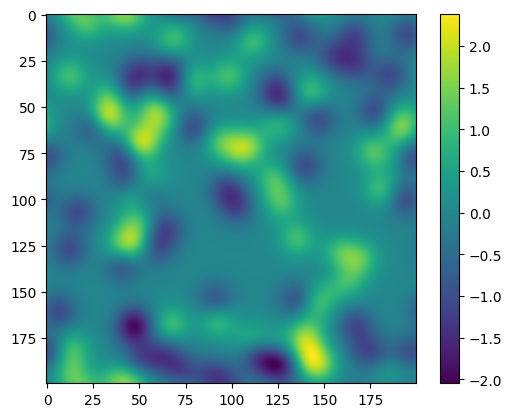

In [22]:
plt.imshow(psi)
plt.colorbar()
plt.show()

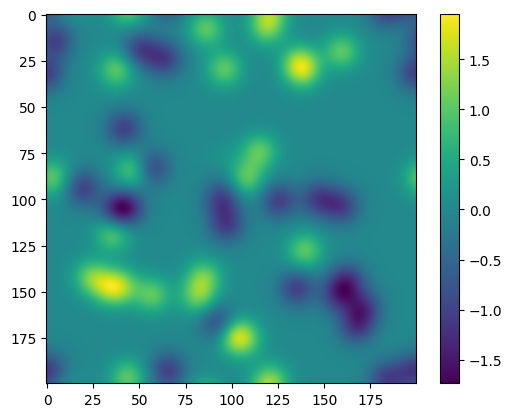

In [23]:
plt.imshow(phi)
plt.colorbar()
plt.show()

In [24]:
phi_x, phi_y = discrete_gradient(phi, dx)

In [25]:
beta = 0.1

In [26]:
u = (- psi_y + beta * phi_x) / np.sqrt(1 + beta**2)

v = (psi_x + beta * phi_y) / np.sqrt(1 + beta**2)

In [27]:
vel_mag = np.sqrt(u**2 + v**2)
max_vel = np.max(vel_mag)
s = nu_max / max_vel

In [28]:
phi *= s * beta / np.sqrt(1 + beta**2)

In [29]:
trA = discrete_laplacian(phi, dx)

sources = np.where(trA > 1e-4, 1, 0)
sinks = np.where(trA < 0, 1, 0)

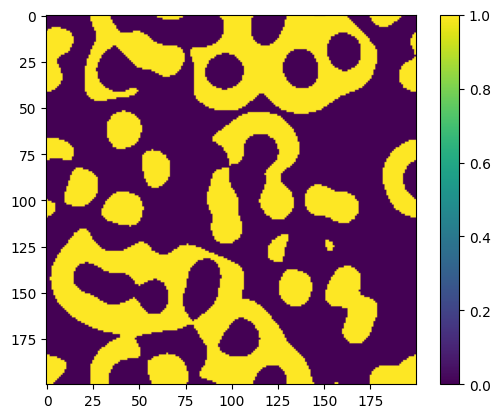

In [30]:
plt.imshow(sources)
plt.colorbar()
plt.show()

In [31]:
in_prime_std = compute_in_prime_std(phi, i_n, dx)
in_pp_std = m_n * in_prime_std / i_n

In [32]:
in_prime_int = compute_in_prime_integral(phi, i_n, N, dx)
in_pp_int = m_n * in_prime_int / i_n

In [33]:
print(in_prime_std, in_pp_std)

911.6474579011119 30.388248596703725


In [34]:
print(in_prime_int, in_pp_int)

2376.905595769088 79.23018652563627


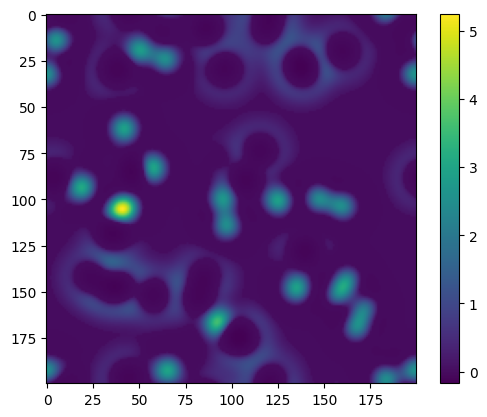

In [35]:
plt.imshow(in_prime_std * trA * sources + in_pp_std * trA * sinks)
plt.colorbar()
plt.show()

In [36]:
np.mean(in_prime_std * trA * sources + in_pp_std * trA * sinks)

np.float64(0.2663114001534041)

In [37]:
i_n / m_n

30.000000000000004

In [38]:
u *= s
v *= s

In [39]:
t, n_list, p_list = solve_system_rk4(n, p, dt, T, u, v, d, i_n, a, m_n, f_p, dx, phi, method)

/tmp/ipykernel_54848/2399023344.py:32: RuntimeWarning: overflow encountered in multiply
  reaction = nutrient_influx + nutrient_outflux - a*p*n/(1 + n) - m_n*n
/tmp/ipykernel_54848/2399023344.py:30: RuntimeWarning: invalid value encountered in multiply
  nutrient_outflux = in_pp * trA * n * sinks
/tmp/ipykernel_54848/2399023344.py:32: RuntimeWarning: invalid value encountered in divide
  reaction = nutrient_influx + nutrient_outflux - a*p*n/(1 + n) - m_n*n
/tmp/ipykernel_54848/2830979407.py:5: RuntimeWarning: invalid value encountered in add
  x = (-np.roll(X,-2,axis = 0) + 16 * np.roll(X,-1,axis = 0) - 30 * X + 16 * np.roll(X,1,axis = 0) - np.roll(X,2,axis = 0) -
/tmp/ipykernel_54848/2830979407.py:5: RuntimeWarning: invalid value encountered in subtract
  x = (-np.roll(X,-2,axis = 0) + 16 * np.roll(X,-1,axis = 0) - 30 * X + 16 * np.roll(X,1,axis = 0) - np.roll(X,2,axis = 0) -
/tmp/ipykernel_54848/3117463668.py:3: RuntimeWarning: invalid value encountered in divide
  reaction = n*p/(1 

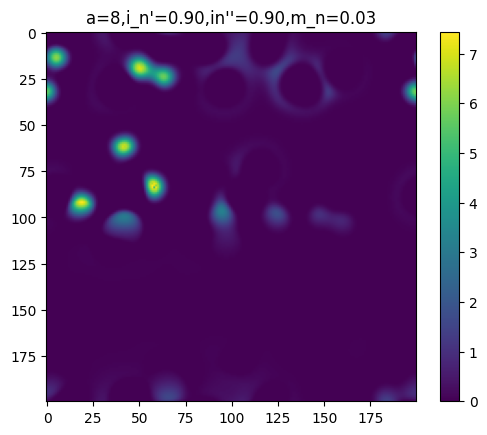

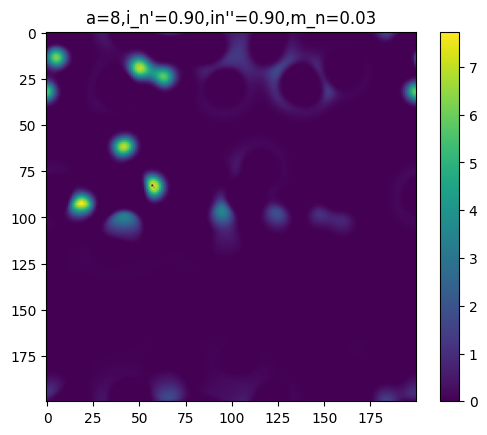

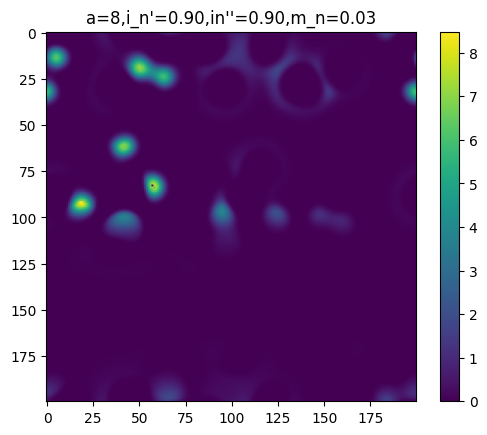

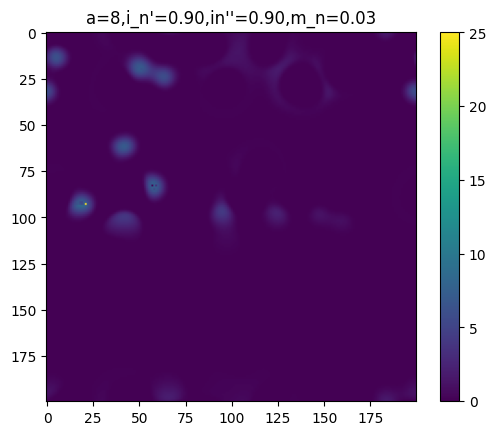

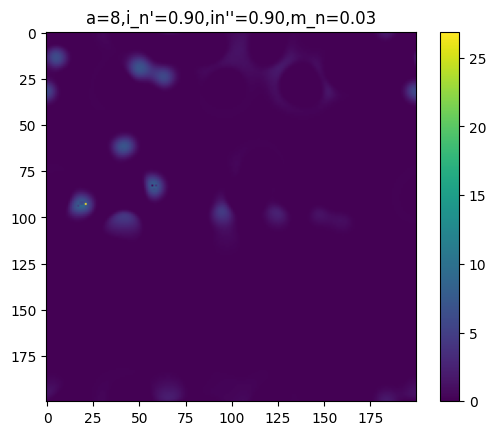

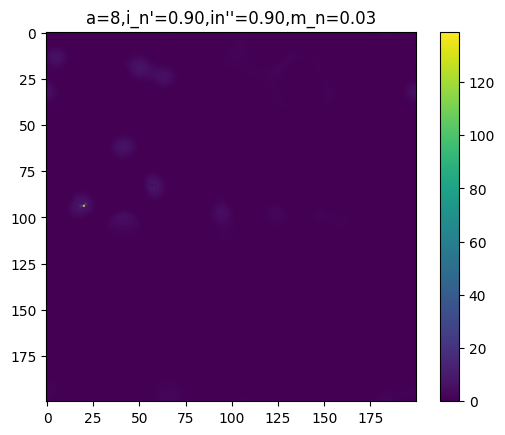

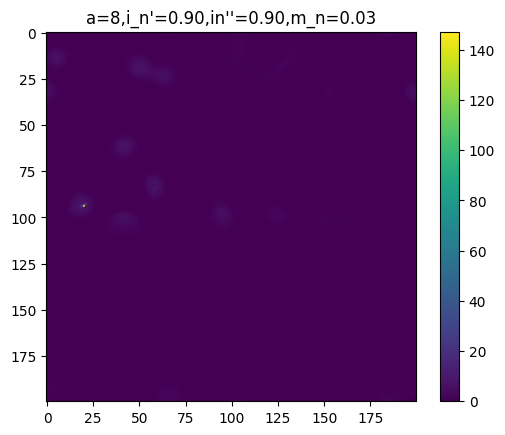

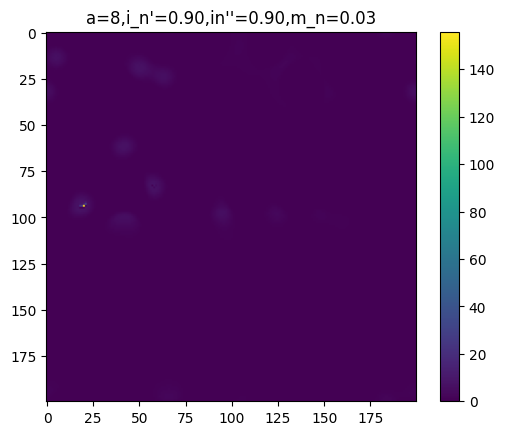

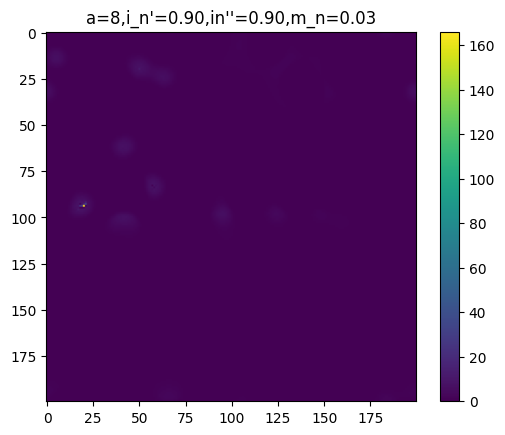

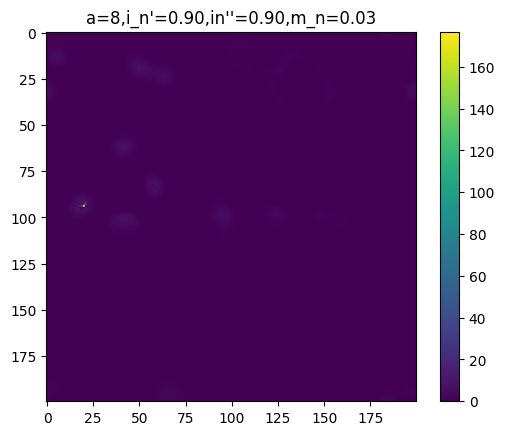

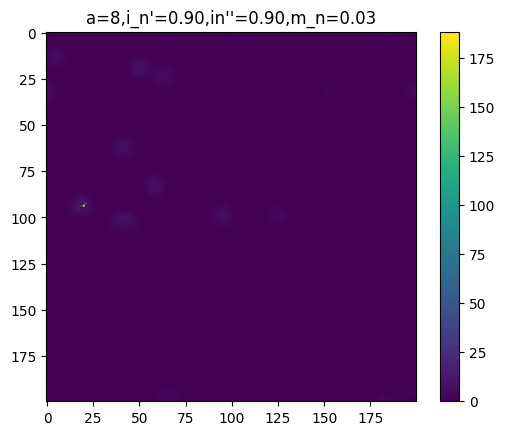

In [48]:
for i in range(11):
    plt.imshow(p_list[80 + i*1])
    plt.title(f'a={a},i_n\'={i_n:.2f},in\'\'={i_n:.2f},m_n={m_n:.2f}')
    plt.colorbar()
    plt.show()

In [41]:
maxi = [np.max(p_list[i]) for i in range(len(p_list))]

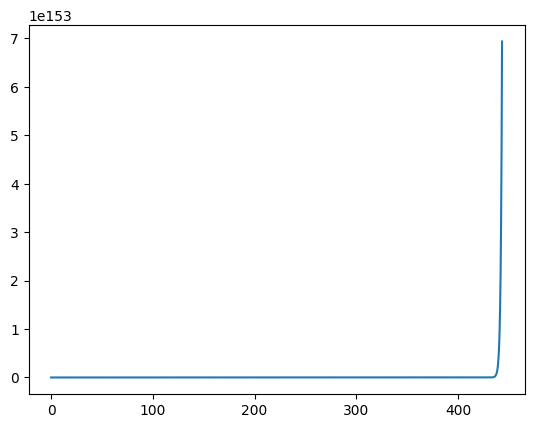

In [42]:
plt.plot(t, maxi)
plt.show()

In [43]:
len(t)

8334

In [44]:
maxi[-1]

np.float64(nan)